# W1. 기상청 ASOS 지상관측 일자료 (서울 108) — 전처리

## 이 데이터는 무엇인가
- **파일**: `data/01_raw/raw_w1_asos.csv` (헤더 없는 원본, 기상청 API 허브 `kma_sfcdd3`)
- **내용**: 서울(관측소 108)의 일별 실제 관측 날씨
- **기간**: 2023-01-01 ~ 2026-07-31 (1,308일)
- **프로젝트에서의 역할**: 분석의 기준이 되는 "그날 실제로 어땠는가" 데이터.
  예보(W2·W3)는 모델 입력용이고, EDA와 이벤트(한파·폭염) 정의는 관측(W1)을 기준으로 한다.


## 진행 단계

| 단계 | 내용 | 상태 |
|---|---|---|
| 1 | 원본 불러오기, 컬럼 이름 붙이기, 이상 날짜 행 제거, 날짜형 변환 |  (1,308행, 중복 날짜 0) |
| 2 | 컬럼 이름 검증 (값이 말이 되는지 확인) |  |
| 3 | 분석에 필요한 컬럼만 선택하고 이름 정리 (선정 이유는 코드 주석에 기록) |  |
| 4 | 결측 표기(-9, -99) 처리 |  |
| 5 | 파생 변수 생성 (일교차, 전일 대비 기온 변화) |  |
| 6 | 검증 (빠진 날, 최저>최고 기온, -9℃ 보존 여부) | |
| 7 | `data/processed/weather_daily.csv` 로 저장 | |

## 결측 처리 규칙 (왜 컬럼별로 다르게 하는가)
기상청은 결측을 -9 또는 -99로 표기하지만, 컬럼마다 -9의 의미가 다르다.

| 컬럼 종류 | 처리 | 이유 |
|---|---|---|
| 기온 (`t_max`, `t_min`, `t_avg`) | -99만 결측 | 서울 겨울에는 -9.0℃가 실제 기온일 수 있다 |
| 습도·풍속·운량 | -9, -99 모두 결측 | 음수가 될 수 없는 값이다 |
| 강수량·신적설 | -9는 **0**(무강수/적설 없음), -99는 결측 | -9는 결측이 아니라 "없음"을 뜻한다 |


In [3]:
import pandas as pd
import numpy as np

w1_columns = [
    'TM', 'STN', 'WS_AVG', 'WR_DAY', 'WD_MAX', 'WS_MAX', 'WS_MAX_TM',
    'WD_INS', 'WS_INS', 'WS_INS_TM', 'TA_AVG', 'TA_MAX', 'TA_MAX_TM',
    'TA_MIN', 'TA_MIN_TM', 'TD_AVG', 'TS_AVG', 'TG_MIN', 'HM_AVG',
    'HM_MIN', 'HM_MIN_TM', 'PV_AVG', 'EV_S', 'EV_L', 'FG_DUR', 'PA_AVG',
    'PS_AVG', 'PS_MAX', 'PS_MAX_TM', 'PS_MIN', 'PS_MIN_TM', 'CA_TOT',
    'SS_DAY', 'SS_DUR', 'SS_CMB', 'SI_DAY', 'SI_60M_MAX', 'SI_60M_MAX_TM',
    'RN_DAY', 'RN_D99', 'RN_DUR', 'RN_60M_MAX', 'RN_60M_MAX_TM',
    'RN_10M_MAX', 'RN_10M_MAX_TM', 'RN_POW_MAX', 'RN_POW_MAX_TM',
    'SD_NEW', 'SD_NEW_TM', 'SD_MAX', 'SD_MAX_TM', 'TE_05', 'TE_10', 'TE_15', 'TE_30', 'TE_50'
]

w1 = pd.read_csv('../data/01_raw/raw_w1_asos.csv', header=None)
w1.columns = w1_columns[:len(w1.columns)]

# 날짜가 0 이하인 이상 행 제거 → 날짜형 변환
w1 = w1[w1['TM'] > 0].copy()
w1['date'] = pd.to_datetime(w1['TM'].astype(str), format='%Y%m%d')
w1 = w1.sort_values('date').reset_index(drop=True)

print(w1.shape, w1['date'].min().date(), '~', w1['date'].max().date())
print('중복 날짜:', w1['date'].duplicated().sum())

(1308, 57) 2023-01-01 ~ 2026-07-31
중복 날짜: 0


In [4]:
w1[['date', 'TA_AVG', 'TA_MAX', 'TA_MIN', 'HM_AVG', 'WS_AVG', 'RN_DAY']].head(5)

,date,TA_AVG,TA_MAX,TA_MIN,HM_AVG,WS_AVG,RN_DAY
0,2023-01-01,-0.2,3.8,-4.3,54.5,2.7,-9.0
1,2023-01-02,-4.5,-0.4,-7.4,45.9,2.5,-9.0
2,2023-01-03,-5.0,0.6,-9.0,49.0,1.8,-9.0
3,2023-01-04,-1.8,3.3,-5.7,51.4,1.9,-9.0
4,2023-01-05,-1.6,3.6,-5.6,58.1,1.6,-9.0


In [6]:
cols = {
    'date': 'date',          # 모든 데이터(예보·특보·네이버)와 합치는 기준 키

    # 기온 — 프로젝트의 핵심 독립변수
    'TA_MAX': 't_max',       # 낮 최고기온: 일교차 계산, 폭염 이벤트 정의(예: 33℃ 이상)에 사용
    'TA_MIN': 't_min',       # 아침 최저기온: 한파 이벤트 정의, 패딩·장갑 등 방한 수요와 직결
    'TA_AVG': 't_avg',       # 평균기온: 체감온도 계산 및 전반적인 더위·추위 수준 파악

    # 강수·날씨 — 우산·레인부츠 등 비 관련 품목의 설명 변수
    'RN_DAY': 'precip_mm',   # 일 강수량: 우산 수요와의 관계 확인, 호우 특보 대조
    'SD_NEW': 'snow_cm',     # 신적설: 눈 오는 날 구분(날씨 유형 파생), 대설 특보 대조

    # 체감에 영향을 주는 보조 변수
    'HM_AVG': 'humidity',    # 습도: 같은 기온이어도 습하면 더 덥게 느껴짐(여름 체감)
    'WS_AVG': 'wind',        # 풍속: 겨울 체감온도 공식에 필요(바람이 세면 더 춥게 느껴짐)
    'CA_TOT': 'cloud',       # 전운량: 맑음/구름많음/흐림 구분용, 비 오는 날 일교차가 작은 이유 해석
}
wd = w1[list(cols)].rename(columns=cols).set_index('date')

# 1) 기온: -99만 결측 (-9는 진짜 기온일 수 있음)
for c in ['t_max', 't_min', 't_avg']:
    wd.loc[wd[c] == -99, c] = np.nan

# 2) 음수 불가능 컬럼: -9, -99 모두 결측
for c in ['humidity', 'wind', 'cloud']:
    wd.loc[wd[c].isin([-9, -99]), c] = np.nan

# 3) 강수·적설: -9는 0(무강수/적설 없음), -99는 진짜 결측
for c in ['precip_mm', 'snow_cm']:
    wd.loc[wd[c] == -9, c] = 0.0
    wd.loc[wd[c] == -99, c] = np.nan

print(wd.isna().sum())
print('무강수(0mm) 일수:', (wd['precip_mm'] == 0).sum())

t_max        0
t_min        0
t_avg        0
precip_mm    0
snow_cm      0
humidity     0
wind         5
cloud        0
dtype: int64
무강수(0mm) 일수: 915


무강수 915일 검증

In [8]:
#  결측 처리 결과 검증
#  무강수 일수가 정의서(754일, -9 표기 기준)와 달라서, 차이가 어디서 오는지 원본(w1)으로 확인한다.

n_minus9 = (w1['RN_DAY'] == -9).sum()   # -9 표기 (결측처럼 보이지만 사실은 무강수)
n_zero   = (w1['RN_DAY'] == 0).sum()    # 원본에 이미 0.0으로 적힌 날
print('RN_DAY == -9 :', n_minus9)
print('RN_DAY == 0  :', n_zero)
print('합계         :', n_minus9 + n_zero, '/ 처리 후 무강수 일수:', (wd['precip_mm'] == 0).sum())

RN_DAY == -9 : 754
RN_DAY == 0  : 161
합계         : 915 / 처리 후 무강수 일수: 915


풍속 결측 5건 처리

In [9]:
print(wd.loc[wd['wind'].isna(), ['t_avg', 'wind']])

            t_avg  wind
date                   
2023-12-10   11.4   NaN
2023-12-11    8.9   NaN
2024-03-11    6.2   NaN
2024-03-12    6.6   NaN
2024-03-14    8.5   NaN


In [10]:
# 풍속 결측은 앞뒤 값으로 선형 보간한다.
# 풍속은 겨울 체감온도 계산에만 쓰는 보조 변수이고, 5건은 전체의 0.4%라 영향이 작다.
# 행을 지우면 날짜가 비어 시계열 분석(차분·시차)이 깨지므로 지우지 않는다.
# [limit=3] 연속 3일까지만 채운다. 더 길게 비어 있으면 값을 지어내는 셈이라 NaN으로 남긴다.
wd['wind'] = wd['wind'].interpolate(limit=3)
print('풍속 결측 남은 개수:', wd['wind'].isna().sum())   # 0이면 성공

풍속 결측 남은 개수: 0


파생 변수 생성

In [11]:
#  핵심 가설은 "소비자는 절대 기온보다 일교차·전일 대비 변화에 더 반응한다"이다.

# 일교차 = 최고기온 - 최저기온
wd['dtr'] = wd['t_max'] - wd['t_min']

# 전일 대비 변화량: diff()는 "오늘 값 - 어제 값".
# 첫날(2023-01-01)은 어제가 없어서 NaN이 되는 게 정상이다.
wd['dt_min'] = wd['t_min'].diff()   # 아침 최저기온 변화: 갑작스러운 추위를 포착
wd['dt_max'] = wd['t_max'].diff()   # 낮 최고기온 변화: 갑작스러운 더위를 포착

wd[['t_min', 't_max', 'dtr', 'dt_min', 'precip_mm']].describe().round(1)

,t_min,t_max,dtr,dt_min,precip_mm
count,1308.0,1308.0,1308.0,1307.0,1308.0
mean,10.2,18.9,8.8,0.0,4.0
std,11.0,10.7,3.2,2.6,12.8
min,-17.3,-8.2,1.0,-13.6,0.0
25%,0.7,9.4,6.5,-1.5,0.0
50%,10.9,20.9,8.6,0.0,0.0
75%,20.0,27.9,11.1,1.4,0.5
max,29.3,38.0,21.1,10.2,128.8


In [12]:
# 1) 달력 대비 빠진 날 (0이어야 함)
full = pd.date_range(wd.index.min(), wd.index.max())
print('빠진 날:', len(full) - len(wd))

# 2) 논리 오류: 최저기온이 최고기온보다 높은 날 (0이어야 함)
print('t_min > t_max:', (wd['t_min'] > wd['t_max']).sum())

# 3) 진짜 -9.0℃ 관측이 보존됐는지 (0보다 커야 함. 0이면 -9를 잘못 지운 것)
print('t_min == -9인 날:', (wd['t_min'] == -9).sum())

빠진 날: 0
t_min > t_max: 0
t_min == -9인 날: 3


In [13]:
import os
os.makedirs('../data/processed', exist_ok=True)
wd.to_csv('../data/processed/weather_daily.csv')

In [14]:
# [검증] 파생 변수와 저장 결과 확인
print('풍속 결측 남은 개수:', wd['wind'].isna().sum())          # 0이어야 함
print('일교차 최솟값:', wd['dtr'].min())                         # 음수면 안 됨
print('dt_min 개수:', wd['dt_min'].notna().sum())              # 1307이어야 함 (첫날 NaN)

# 저장된 파일을 다시 읽어서 같은지 확인
chk = pd.read_csv('../data/processed/weather_daily.csv', index_col='date', parse_dates=True)
print(chk.shape, chk.index.min().date(), '~', chk.index.max().date())

풍속 결측 남은 개수: 0
일교차 최솟값: 1.0
dt_min 개수: 1307
(1308, 11) 2023-01-01 ~ 2026-07-31


# T1. 네이버 데이터랩 쇼핑인사이트 — 카테고리별 클릭지수

## 이 데이터는 무엇인가
- **파일**: `data/raw/datalab_category/all_years.csv`
- **내용**: 쇼핑 카테고리(패션의류, 여성의류 등)별 **일별 클릭지수**
- **기간**: 2023-01-01 ~ 2026-07-31 (기상 데이터와 같은 1,308일)
- **프로젝트에서의 역할**: 패션 수요를 나타내는 **메인 타깃(종속변수)**.
  W1에서 만든 날씨 변수(`weather_daily.csv`)와 `date`로 합쳐서 "날씨가 수요를 움직이는가"를 본다.

## 이번 단계에서 확인할 것

| # | 확인 항목 | 왜 확인하나 | 결과 |
|---|---|---|---|
| 1 | 행 수, 컬럼 이름, 자료형 | 어떤 정보가 어떤 형태로 들어 있는지 파악 |  |
| 2 | `batch_id` 개수와 앵커(`is_anchor`) 행 | 배치 구조를 이해해야 스케일 문제를 다룰 수 있다 |  |
| 3 | 날짜 범위와 고유 날짜 수 (1,308일인가) | 날짜가 빠지면 기상 데이터와 합칠 때 어긋난다 |  |
| 4 | 카테고리 종류 (대분류 / 중분류) | 어떤 단위로 분석할 수 있는지 파악 |  |
| 5 | 결측·중복 확인 | 정제가 필요한지 판단 | |
| 6 | 카테고리 몇 개를 그래프로 그려 보기 | 값이 상식에 맞는지 눈으로 확인 |  |


T1 (쇼핑인사이트 카테고리 클릭지수) 구조 파악

In [16]:
t1 = pd.read_csv('../data/raw/datalab_category/all_years.csv', parse_dates=['date'])   # 경로는 본인 폴더에 맞게 수정

print(t1.shape)
display(t1.head(10))
t1.info()

(27468, 12)


,date,source,category_l1,category_l2,keyword,ratio,rescaled,batch_id,gender,age_group,cid,is_anchor
0,2023-01-01,naver_datalab_category,패션의류,NaN,NaN,62.39821,1.000000,cat_b01,NaN,NaN,50000000,True
1,2023-01-01,naver_datalab_category,패션의류,여성의류,NaN,32.50333,0.520902,cat_b01,NaN,NaN,50000167,False
2,2023-01-01,naver_datalab_category,패션의류,남성의류,NaN,21.83542,0.349937,cat_b01,NaN,NaN,50000169,False
3,2023-01-02,naver_datalab_category,패션의류,NaN,NaN,59.89473,1.000000,cat_b01,NaN,NaN,50000000,True
4,2023-01-02,naver_datalab_category,패션의류,여성의류,NaN,31.48755,0.525715,cat_b01,NaN,NaN,50000167,False
5,2023-01-02,naver_datalab_category,패션의류,남성의류,NaN,20.78627,0.347047,cat_b01,NaN,NaN,50000169,False
6,2023-01-03,naver_datalab_category,패션의류,NaN,NaN,61.79215,1.000000,cat_b01,NaN,NaN,50000000,True
7,2023-01-03,naver_datalab_category,패션의류,여성의류,NaN,33.09678,0.535615,cat_b01,NaN,NaN,50000167,False
8,2023-01-03,naver_datalab_category,패션의류,남성의류,NaN,21.04185,0.340526,cat_b01,NaN,NaN,50000169,False
9,2023-01-04,naver_datalab_category,패션의류,NaN,NaN,61.23059,1.000000,cat_b01,NaN,NaN,50000000,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         27468 non-null  datetime64[ns]
 1   source       27468 non-null  object        
 2   category_l1  27468 non-null  object        
 3   category_l2  18312 non-null  object        
 4   keyword      0 non-null      float64       
 5   ratio        27468 non-null  float64       
 6   rescaled     27468 non-null  float64       
 7   batch_id     27468 non-null  object        
 8   gender       0 non-null      float64       
 9   age_group    0 non-null      float64       
 10  cid          27468 non-null  int64         
 11  is_anchor    27468 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(5), int64(1), object(4)
memory usage: 2.3+ MB


In [17]:
print('batch_id 개수:', t1['batch_id'].nunique())
print('앵커 행 수:', t1['is_anchor'].sum())
print('날짜 범위:', t1['date'].min().date(), '~', t1['date'].max().date())
print('고유 날짜 수:', t1['date'].nunique())   # 1308이면 3년 치 전부 있음

batch_id 개수: 7
앵커 행 수: 9156
날짜 범위: 2023-01-01 ~ 2026-07-31
고유 날짜 수: 1308


- 컬럼 구성: `ratio`(네이버 원본 지수), `rescaled`(ratio ÷ 그날 앵커 ratio), `category_l1/l2`, `cid`, `batch_id`, `is_anchor`
- 배치 구조: 배치 1개 = 앵커(패션의류) 1 + 중분류 2. 7배치 → 중분류 14개
- 궁금한 점: 앵커의 `ratio`가 배치마다 같은지? (같아야 `ratio`를 그대로 비교할 수 있다)

카테고리 종류와 중복·결측

In [18]:
#T1 카테고리 구성과 데이터 품질 확인

cat_info = (
    t1[~t1['is_anchor']]
    .groupby(['category_l2', 'cid', 'batch_id'])
    .agg(days=('date', 'nunique'))
    .reset_index()
    .sort_values('batch_id')
)
display(cat_info)

,category_l2,cid,batch_id,days
2,남성의류,50000169,cat_b01,1308
10,여성의류,50000167,cat_b01,1308
1,남성신발,50000174,cat_b02,1308
9,여성신발,50000173,cat_b02,1308
0,남성가방,50000177,cat_b03,1308
8,여성가방,50000176,cat_b03,1308
4,모자,50000181,cat_b04,1308
7,양말,50000166,cat_b04,1308
12,장갑,50000182,cat_b05,1308
13,주얼리,50000189,cat_b05,1308


In [19]:
# 2) 날짜 × 카테고리 조합이 중복되지 않는가 (0이어야 함)
dup = t1.duplicated(subset=['date', 'category_l1', 'category_l2', 'batch_id']).sum()
print('날짜×카테고리×배치 중복:', dup)

# 3) 핵심 컬럼의 결측 (ratio, rescaled는 0이어야 함)
print(t1[['ratio', 'rescaled']].isna().sum())

날짜×카테고리×배치 중복: 0
ratio       0
rescaled    0
dtype: int64


In [20]:
# 4) 앵커의 ratio가 배치마다 같은가
# 앵커는 매 요청에 들어가고 요청마다 같은 3년 기간이라, 값이 같다면 배치 간 스케일이 같다는 뜻이다.
#      같으면 ratio를 그대로 써도 되고, 다르면 배치별로 보정이 필요하다.
anc = t1[t1['is_anchor']].pivot_table(index='date', columns='batch_id', values='ratio')
print('배치별 앵커 ratio 최대 편차:', (anc.max(axis=1) - anc.min(axis=1)).max())
display(anc.head(3))

배치별 앵커 ratio 최대 편차: 0.0


batch_id,cat_b01,cat_b02,cat_b03,cat_b04,cat_b05,cat_b06,cat_b07
date,,,,,,,
2023-01-01,62.39821,62.39821,62.39821,62.39821,62.39821,62.39821,62.39821
2023-01-02,59.89473,59.89473,59.89473,59.89473,59.89473,59.89473,59.89473
2023-01-03,61.79215,61.79215,61.79215,61.79215,61.79215,61.79215,61.79215


T1 "날짜 × 카테고리

In [21]:
t1_wide = (
    t1[~t1['is_anchor']]
    .pivot_table(index='date', columns='category_l2', values='ratio')
)

# 앵커(패션의류 전체)는 배치마다 같은 값이라 한 배치에서만 가져온다.
fashion_all = t1[t1['is_anchor'] & (t1['batch_id'] == 'cat_b01')].set_index('date')['ratio']
t1_wide['패션의류_전체'] = fashion_all

print(t1_wide.shape)            # (1308, 15)여야 함 (중분류 14 + 패션의류 전체 1)
display(t1_wide.head(3))

(1308, 15)


category_l2,남성가방,남성신발,남성의류,등산,모자,선케어,수영,양말,여성가방,여성신발,여성의류,우산,장갑,주얼리,패션의류_전체
date,,,,,,,,,,,,,,,
2023-01-01,2.61107,9.88195,21.83542,15.56695,3.24602,0.68872,2.38666,5.26592,8.63667,10.30591,32.50333,0.29178,1.24443,5.85901,62.39821
2023-01-02,2.56717,9.82602,20.78627,15.34082,3.09975,0.73650,2.87287,4.77588,8.26931,10.09978,31.48755,0.27955,1.30281,5.58400,59.89473
2023-01-03,2.47654,9.52162,21.04185,14.84504,3.08737,0.75890,2.95198,4.94851,8.33548,10.02426,33.09678,0.30946,1.39619,5.82124,61.79215


날씨 민감 후보 카테고리 시계열 그래프

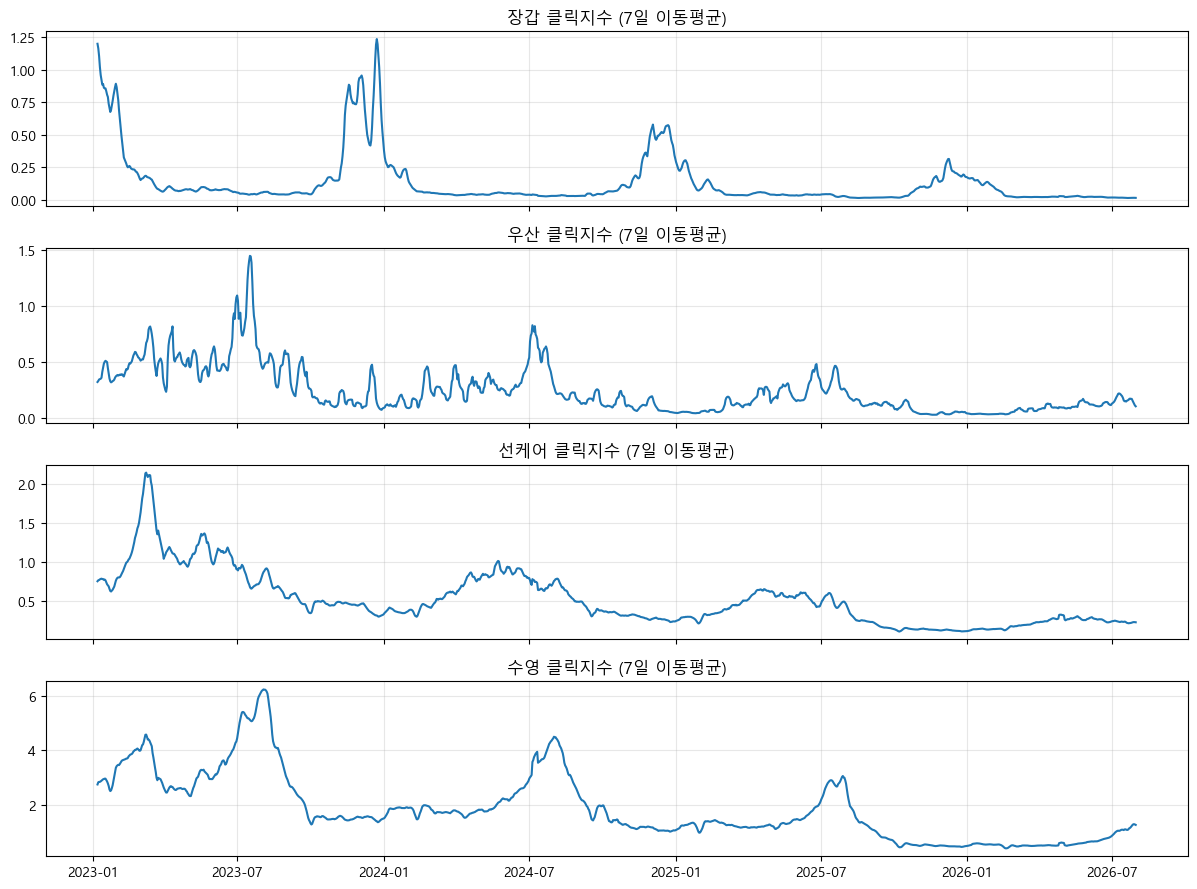

In [22]:
# 일별 값은 요일 효과(주말/평일) 때문에 들쭉날쭉해서 큰 흐름이 안 보인다.
# 7일 평균을 내면 요일 효과가 줄어 계절 패턴이 잘 드러난다.
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기준. macOS는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

targets = ['장갑', '우산', '선케어', '수영']

fig, axes = plt.subplots(len(targets), 1, figsize=(12, 9), sharex=True)
for ax, name in zip(axes, targets):
    ax.plot(t1_wide.index, t1_wide[name].rolling(7).mean())
    ax.set_title(f'{name} 클릭지수 (7일 이동평균)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

장기 추세 확인

In [23]:
yearly = t1_wide['패션의류_전체'].groupby(t1_wide.index.year).mean().round(1)
print(yearly)

date
2023    50.3
2024    35.6
2025    21.9
2026    11.8
Name: 패션의류_전체, dtype: float64


### 확인한 내용
- 장갑: 매년 11~1월에 정점 / 수영: 매년 7~8월 정점 / 우산: 7월 근처 + 비 오는 날 스파이크로 들쭉날쭉 → 가설과 일치
- 선케어: 정점이 3~5월(봄)이고 여름에는 내려감 → 가설("여름에 높다")과 다름. 이유는 확인 필요
- **장기 하락**: 패션의류 전체 연평균 50.3 → 35.6 → 21.9 → 11.8. 같은 계절의 정점도 해마다 낮아짐
- 주의: 2026은 1~7월만 있어 연평균을 그대로 비교하면 안 됨

하락의 크기 확인과 점유율 보정

In [24]:
# 1~7월만 비교해서 연도별 하락 크기를 공정하게 구하기
# 2026은 1~7월 데이터뿐이라, 12개월 평균과 비교하면 계절 차이가 섞인다.
#      모든 연도에서 같은 달(1~7월)만 골라 평균을 내면 기간이 같아져 공정하다.
jan_jul = t1_wide[t1_wide.index.month <= 7]
yearly_same = jan_jul.groupby(jan_jul.index.year).mean()

show = ['패션의류_전체', '장갑', '우산', '선케어', '수영']
print('[1~7월 연도별 평균]')
display(yearly_same[show].round(2))

# 절대값은 카테고리마다 크기가 달라 비교하기 어렵다.
#        2023년을 1.0으로 맞춘 비율로 보면 "얼마나 떨어졌는가"가 한눈에 보인다.
print('[2023년 = 1.0 기준 비율]')
display((yearly_same[show] / yearly_same.loc[2023, show]).round(2))

[1~7월 연도별 평균]


category_l2,패션의류_전체,장갑,우산,선케어,수영
date,,,,,
2023,54.61,0.23,0.56,1.08,3.58
2024,36.96,0.07,0.30,0.65,2.22
2025,25.81,0.07,0.18,0.47,1.55
2026,11.80,0.04,0.09,0.21,0.63


[2023년 = 1.0 기준 비율]


category_l2,패션의류_전체,장갑,우산,선케어,수영
date,,,,,
2023,1.00,1.00,1.00,1.00,1.00
2024,0.68,0.32,0.53,0.60,0.62
2025,0.47,0.30,0.32,0.43,0.43
2026,0.22,0.19,0.16,0.20,0.18


In [25]:
# 점유율 만들기: 카테고리 클릭 ÷ 패션의류 전체 클릭
# 전체가 내려가는 공통 하락은 분자와 분모에 똑같이 들어 있어서, 나누면 상쇄된다.
# 0.01 같은 작은 비율보다 1.0(%)처럼 읽는 게 직관적이다.
t1_share = t1_wide.drop(columns='패션의류_전체').div(t1_wide['패션의류_전체'], axis=0) * 100
display(t1_share[['장갑', '우산', '선케어', '수영']].describe().round(2))

category_l2,장갑,우산,선케어,수영
count,1308.00,1308.00,1308.00,1308.00
mean,0.39,0.76,1.62,5.98
std,0.45,0.61,0.67,3.35
min,0.07,0.11,0.53,1.86
25%,0.14,0.30,1.00,3.80
50%,0.18,0.62,1.60,4.93
75%,0.38,1.00,2.19,6.74
max,3.36,5.12,3.21,19.58


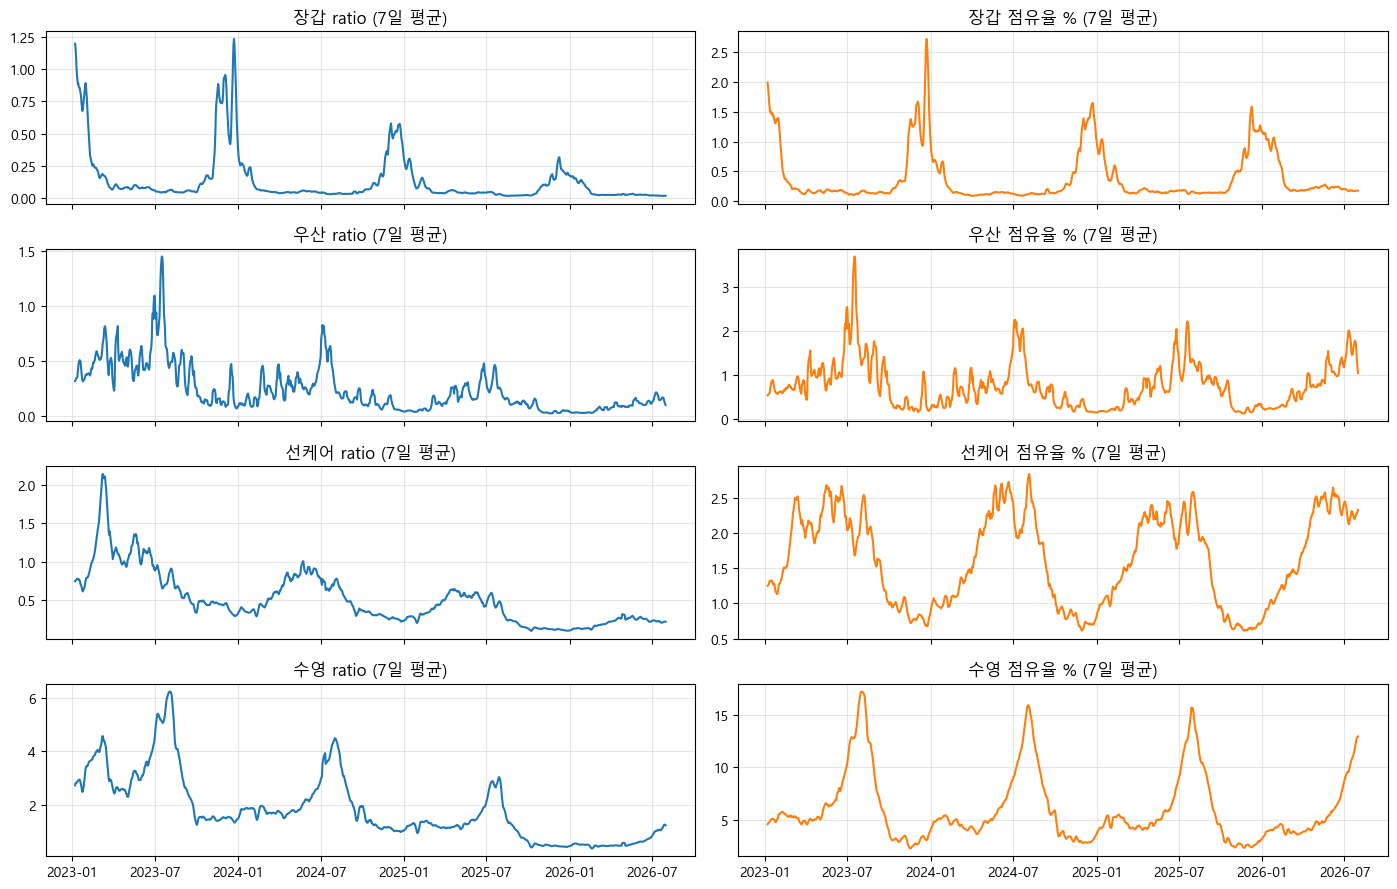

In [26]:
# 원래 값(ratio)과 점유율(share)을 나란히 그려서 하락이 걷히는지 보기
targets = ['장갑', '우산', '선케어', '수영']

fig, axes = plt.subplots(len(targets), 2, figsize=(14, 9), sharex=True)
for i, name in enumerate(targets):
    axes[i, 0].plot(t1_wide[name].rolling(7).mean())
    axes[i, 0].set_title(f'{name} ratio (7일 평균)')
    axes[i, 1].plot(t1_share[name].rolling(7).mean(), color='tab:orange')
    axes[i, 1].set_title(f'{name} 점유율 % (7일 평균)')
    for ax in axes[i]:
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### T1-6 확인한 내용 (수정)
- 장갑: 매년 11~1월 정점 / 수영: 매년 7월 정점 / 우산: 7월 근처 + 비 오는 날 스파이크 → 가설과 일치
- ~~선케어: 봄 정점~~ → **점유율로 보면 4~7월 고원**. ratio에서 봄 정점으로 보인 건 전체 하락이 만든 착시

### T1-7 확인한 내용
- 1~7월 기준 2023 대비 2026: 패션의류 전체 0.22, 장갑 0.19, 우산 0.16, 선케어 0.20, 수영 0.18 → 하락은 대부분 카테고리 공통
- 점유율로 바꾸면 수영·선케어·우산의 연도별 정점 높이가 비슷해짐 (공통 하락이 상쇄됨)
- 장갑은 2023~24 겨울 정점이 이후보다 높음 → 겨울 날씨 차이 가능성, 날씨와 맞춰 확인 필요
- 한계: 점유율은 패션의류 전체와 함께 움직이는 요인도 제거함 → ratio와 점유율을 둘 다 두고 비교

T1-8. 날씨와 수요 연결: 원 시계열 상관 vs 단기 변동 상관

In [27]:
# 날씨(W1)와 T1 점유율을 날짜 기준으로 합치기
# 수요와 날씨를 같은 날짜끼리 짝지어야 상관을 구할 수 있다.
# 둘 다 date가 인덱스고 1,308일이 똑같아서, 인덱스 기준 join이면 행이 늘거나 줄지 않는다.
wd = pd.read_csv('../data/processed/weather_daily.csv', index_col='date', parse_dates=True)

targets = ['장갑', '우산', '선케어', '수영']
df = t1_share[targets].join(wd[['t_min', 't_max', 'dtr', 'dt_min', 'precip_mm']])


print(df.shape)
print(df.isna().sum())

(1308, 9)
장갑           0
우산           0
선케어          0
수영           0
t_min        0
t_max        0
dtr          0
dt_min       1
precip_mm    0
dtype: int64


In [28]:
# 1단계 — 원 시계열 상관 (계절 효과가 섞인 상태)
# 점유율은 값이 커질수록 변동폭도 커져서(곱셈형), 로그를 취하면 "몇 % 늘었나"로 읽을 수 있다.
# 강수는 0mm인 날이 많아 log(0)이 불가능하다. log1p는 log(1+x)라서 0도 안전하다.
y = np.log(df[targets])
x = pd.DataFrame({
    't_min': df['t_min'],
    't_max': df['t_max'],
    'log_precip': np.log1p(df['precip_mm']),
})

raw_corr = pd.DataFrame({v: y.corrwith(x[v]) for v in x.columns})
print('[원 시계열 상관]')
display(raw_corr.round(2))

[원 시계열 상관]


,t_min,t_max,log_precip
장갑,-0.71,-0.72,-0.20
우산,0.66,0.59,0.49
선케어,0.57,0.62,0.05
수영,0.69,0.63,0.21


In [29]:
# 단기 변동만 남기고 상관 구하기
# "평소 수준 = 앞뒤 31일 이동평균"을 빼면 천천히 변하는 계절·장기 하락이 사라지고,
#  그날만의 튀는 부분(평소보다 얼마나 높고 낮았나)만 남는다.
# [center=True] 앞뒤 날을 같이 써서 평소 수준이 뒤로 밀리지 않게 한다.
# [min_periods=15] 데이터 양 끝(처음·마지막 15일)은 창이 반만 차서, 최소 15개가 있으면 계산한다.
def short_term(s, window=31):
    return s - s.rolling(window, center=True, min_periods=15).mean()

y_st = y.apply(short_term)
x_st = x.apply(short_term)

st_corr = pd.DataFrame({v: y_st.corrwith(x_st[v]) for v in x.columns})
print('[단기 변동 상관 (창=31일)]')
display(st_corr.round(2))

[단기 변동 상관 (창=31일)]


,t_min,t_max,log_precip
장갑,-0.46,-0.27,-0.16
우산,0.16,-0.23,0.62
선케어,0.18,0.34,-0.24
수영,0.21,0.15,-0.01


In [30]:
# 창 길이를 바꿔도 결론이 같은지 확인 (강건성 점검)
# 31일은 내가 임의로 정한 값이다. 15일·61일로 바꿔도 비슷하면 결론이 창 선택에 좌우되지 않는다는 근거가 된다.
rows = []
for w in [15, 31, 61]:
    ys = y.apply(lambda s: short_term(s, w))
    xs = x.apply(lambda s: short_term(s, w))
    rows.append({
        '창(일)': w,
        '장갑×t_min':    ys['장갑'].corr(xs['t_min']),
        '선케어×t_max':  ys['선케어'].corr(xs['t_max']),
        '수영×t_max':    ys['수영'].corr(xs['t_max']),
        '우산×log강수':  ys['우산'].corr(xs['log_precip']),
    })
display(pd.DataFrame(rows).set_index('창(일)').round(2))

,장갑×t_min,선케어×t_max,수영×t_max,우산×log강수
창(일),,,,
15,-0.38,0.30,0.08,0.62
31,-0.46,0.34,0.15,0.62
61,-0.45,0.34,0.13,0.62


### T1-8 확인한 내용
- 합치기: 1,308행 × 9컬럼, 결측은 dt_min 첫날 1개뿐(정상)
- 원 시계열 상관은 계절 때문에 부풀려짐. 단기 변동(31일 이동평균 제거)으로 바꾸면:
  - 장갑×t_min -0.71 → **-0.46** (추위 신호가 남음)
  - 선케어×t_max 0.62 → 0.34 / 수영×t_max 0.63 → 0.15 / 우산×t_min 0.66 → 0.16
  - 우산×log강수 0.49 → **0.62** (오히려 증가, 창 길이 15·31·61일 모두 0.62로 안정)
- 교란 예: 우산×t_max가 -0.23 (비 오는 날이 서늘해서. 우산은 기온이 아니라 비에 반응할 가능성)
- 수영×t_max는 창 길이에 따라 0.08~0.15로 불안정 → 일 단위 날씨 반응은 약함
- 한계: 연중 전체로 구한 값이라 비수기 노이즈가 섞임 → 성수기만 따로 확인 필요

성수기 한정(월평균 점유율이 최고 달의 40% 이상인 달) + 시차(lag) 확인
비수기(여름의 장갑)는 값이 너무 작아서 변동이 노이즈일 수 있다. 

In [31]:
# 카테고리별 성수기 월을 데이터로 정하기
month_mean = t1_share[targets].groupby(t1_share.index.month).mean()
active = {k: [m for m in range(1, 13) if month_mean.loc[m, k] >= 0.4 * month_mean[k].max()]
          for k in targets}
for k, v in active.items():
    print(f'{k}: 성수기 {v}')

장갑: 성수기 [1, 11, 12]
우산: 성수기 [4, 5, 6, 7, 8, 9]
선케어: 성수기 [1, 2, 3, 4, 5, 6, 7, 8, 9]
수영: 성수기 [5, 6, 7, 8, 9]


In [32]:
# 성수기 한정 단기 변동 상관

pairs = {'장갑': 't_min', '선케어': 't_max', '수영': 't_max', '우산': 'log_precip'}

rows = []
for k, v in pairs.items():
    mask = x_st.index.month.isin(active[k])
    rows.append({
        '쌍': f'{k}×{v}',
        '전 기간': y_st[k].corr(x_st[v]),
        '성수기만': y_st[k][mask].corr(x_st[v][mask]),
        '성수기 일수': int(mask.sum()),
    })
display(pd.DataFrame(rows).set_index('쌍').round(2))

,전 기간,성수기만,성수기 일수
쌍,,,
장갑×t_min,-0.46,-0.79,307
선케어×t_max,0.34,0.30,1032
수영×t_max,0.15,0.13,551
우산×log_precip,0.62,0.64,671


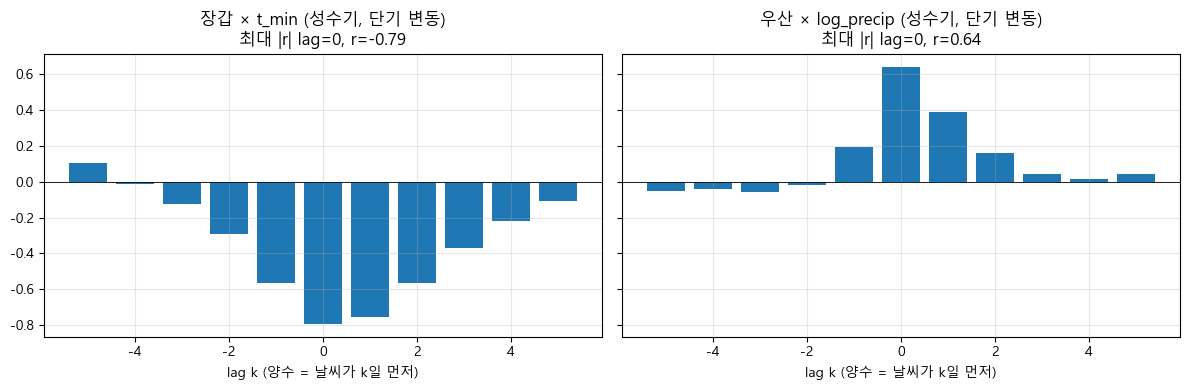

In [33]:
# 시차(lag) 상관: corr(수요[t], 날씨[t-k])
def lag_corr(y, x, mask, max_lag=5):
    return pd.Series({k: y.where(mask).corr(x.shift(k)) for k in range(-max_lag, max_lag + 1)})

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (k, v) in zip(axes, [('장갑', 't_min'), ('우산', 'log_precip')]):
    mask = pd.Series(x_st.index.month.isin(active[k]), index=x_st.index)
    c = lag_corr(y_st[k], x_st[v], mask)
    ax.bar(c.index, c.values)
    ax.set_title(f'{k} × {v} (성수기, 단기 변동)\n최대 |r| lag={c.abs().idxmax()}, r={c[c.abs().idxmax()]:.2f}')
    ax.set_xlabel('lag k (양수 = 날씨가 k일 먼저)')
    ax.axhline(0, color='k', lw=0.6)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# 성수기 기준(%)을 바꿔도 결론이 같은지 확인 (강건성 점검)
# [왜 월평균 점유율] 장기 하락이 걷힌 값이라 월 간 비교가 공정하다.
month_mean = t1_share[targets].groupby(t1_share.index.month).mean()
pairs = {'장갑': 't_min', '선케어': 't_max', '수영': 't_max', '우산': 'log_precip'}

rows = []
for ratio in [0.3, 0.4, 0.5, 0.6]:
    row = {'기준(%)': int(ratio * 100)}
    for k, v in pairs.items():
        months = [m for m in range(1, 13) if month_mean.loc[m, k] >= ratio * month_mean[k].max()]
        mask = x_st.index.month.isin(months)
        row[f'{k}×{v}'] = y_st[k][mask].corr(x_st[v][mask])
        row[f'{k} 일수'] = int(mask.sum())
    rows.append(row)

display(pd.DataFrame(rows).set_index('기준(%)').round(2))

,장갑×t_min,장갑 일수,선케어×t_max,선케어 일수,수영×t_max,수영 일수,우산×log_precip,우산 일수
기준(%),,,,,,,,
30,-0.79,307,0.34,1308,0.03,1032,0.62,795
40,-0.79,307,0.30,1032,0.13,551,0.64,671
50,-0.79,307,0.32,908,0.19,337,0.64,461
60,-0.79,307,0.36,705,0.27,217,0.62,337


### T1-9 추가 해석: 선케어·수영은 날씨보다 달력(시즌) 요인이 클 가능성

| 카테고리 | 데이터에서 보인 것 | 내 해석 |
|---|---|---|
| 선케어 | 점유율이 4~7월에 24~28% 고원으로 일정하게 유지됨. 일 단위 기온 상관은 약함(0.30) | 날씨에 일희일비하기보다 **계절 단위로 꾸준히 쓰는 필수품**이라고 생각. 평소에도 많이 사용되는 제품이라 일별 날씨 변동에 덜 민감할 수 있음 |
| 수영 | 상관이 성수기 기준(30~60%)에 따라 0.03~0.27로 흔들림. 7월 정점은 해마다 비슷함 | 날씨보다 **휴가철·강습·취미 일정 같은 달력 요인**이 클 가능성 생각 |

- 대비: 장갑·우산은 **그날의 날씨**에 반응하는 모양이고, 선케어·수영은 **달력(시즌)이 정하는 수요**의 모양이다.
- 주의: 위 해석은 데이터 모양과 상식에 기반한 **가설**이며, 이 데이터로 증명한 것은 아님.
- 확인 예정: 선케어는 기온보다 햇빛(운량)과의 관계가 더 클 수 있어 운량으로 확인. 수영은 T3(래쉬가드·아쿠아슈즈 등 야외 물놀이 키워드)와 비교.

## T1-10. 지속성을 걷어낸 시차 상관 (차분 CCF) + 겨울별 일관성

### 하는 일
1. 수요와 날씨를 각각 **전날 대비 변화량(차분)** 으로 바꾼 뒤 시차 상관을 다시 구한다.
2. 장갑×최저기온 상관을 **겨울마다 따로** 구해서 일관성을 본다

### 왜 하는가
- 추위·비가 며칠씩 이어지면 어제 날씨와 오늘 날씨가 거의 같은 값이라 lag 0, 1, 2가 모두 크게 나온다. 반응이 하루 늦어서가 아니라 날씨가 이어져서 생기는 모양이다.
- 차분하면 "며칠째 추웠나"가 아니라 "그날 갑자기 변했나"만 남아서, 수요가 **어느 날에 뛰는지**가 드러난다.
- 성수기 307일은 사실상 겨울 4번이다. 같은 겨울 안의 날들은 서로 비슷하게 움직여서 독립적인 관측 수는 307보다 훨씬 적다. 한 겨울이 결과 전체를 끌고 가는지 확인해야 한다.

차분한 시차 그래프

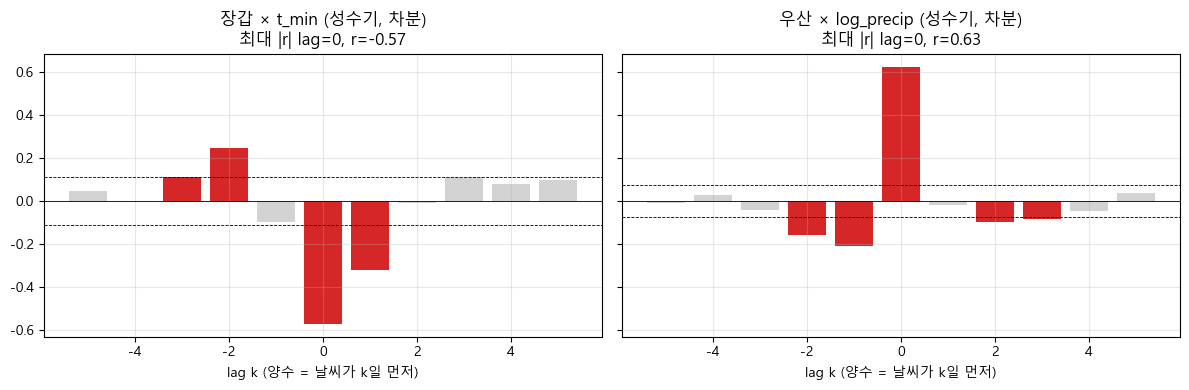

In [36]:
# 차분한 시차 상관 (장갑×최저기온, 우산×log강수)
def lag_corr(y, x, mask, max_lag=5):
    # corr(수요[t], 날씨[t-k]): k > 0이면 날씨가 먼저, 수요가 뒤따르는 구조
    return pd.Series({k: y.where(mask).corr(x.shift(k)) for k in range(-max_lag, max_lag + 1)})

cases = [('장갑', 't_min'), ('우산', 'log_precip')]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (k, v) in zip(axes, cases):
    mask = pd.Series(x_st.index.month.isin(active[k]), index=x_st.index)
    c = lag_corr(y_st[k].diff(), x_st[v].diff(), mask)
    ci = 1.96 / np.sqrt(mask.sum())

    colors = ['tab:red' if abs(val) > ci else 'lightgray' for val in c.values]
    ax.bar(c.index, c.values, color=colors)
    ax.axhline(ci, ls='--', c='k', lw=0.6)
    ax.axhline(-ci, ls='--', c='k', lw=0.6)
    ax.axhline(0, color='k', lw=0.6)
    best = c.abs().idxmax()
    ax.set_title(f'{k} × {v} (성수기, 차분)\n최대 |r| lag={best}, r={c[best]:.2f}')
    ax.set_xlabel('lag k (양수 = 날씨가 k일 먼저)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

겨울별 일관성

In [37]:
# 겨울마다 장갑×최저기온 상관이 일관적인지 확인
# 성수기 307일은 사실 겨울 4번이다. 한 겨울이 결과 전체를 끌고 가는지 확인한다.
# [winter_id] 11~12월은 그 해, 1월은 전해의 겨울에 속하게 묶는다. (예: 2023-01 → 2022 겨울)
#             7월 이전(1~6월)이면 연도에서 1을 뺀다는 규칙이다.
# [주의] 2022 겨울은 데이터가 2023년 1월뿐이라 약 31일만 있다. 일수가 적으면 결과를 크게 믿지 않는다.
s = x_st.index.to_series()
winter_id = s.dt.year - (s.dt.month < 7).astype(int)

mask_g = x_st.index.month.isin(active['장갑'])      # 장갑 성수기 날만
rows = []
for w, dates in s[mask_g].groupby(winter_id[mask_g]):
    rows.append({
        '겨울(시작 연도)': w,
        '일수': len(dates),
        '장갑×t_min': y_st['장갑'][dates.values].corr(x_st['t_min'][dates.values]),
    })
display(pd.DataFrame(rows).set_index('겨울(시작 연도)').round(2))

,일수,장갑×t_min
겨울(시작 연도),,
2022,31,-0.53
2023,92,-0.88
2024,92,-0.71
2025,92,-0.82


### T1-10 확인한 내용
- 차분 시차 그래프(성수기, 유의선 ±1.96/√n 기준)
  - 장갑×t_min: lag 0 **-0.57**, lag 1 **-0.32**만 의미 있게 남음 → 추워진 당일에 가장 크게 반응하고 다음 날까지 일부 이어짐 (차분 전엔 lag 0·1이 -0.79/-0.75로 구분 불가였음)
  - 우산×log강수: lag 0만 **+0.63**. 차분 전 lag 1의 0.39는 비의 지속성 때문이었고 차분 후 사라짐 → 비 온 당일 즉시 반응형
  - 양옆의 반대 부호 막대(장갑 lag -2의 +0.25, 우산 lag -2·-1·2·3의 음수)는 차분과 날씨 자체의 패턴이 만든 기계적 효과로 보고 해석하지 않음
- 겨울별 장갑×t_min: 2022-23 -0.53(31일) / 2023-24 -0.88 / 2024-25 -0.71 / 2025-26 -0.82 → 4번 모두 음수로 일관. 한 겨울이 결과를 끌고 가지 않음
- 한계: 독립적인 겨울이 4번뿐이라 상관의 정확한 크기는 확정하기 어려움. 상관이 인과를 증명하지는 않음

14개 카테고리 전체의 날씨 민감도 스크리닝

In [38]:
assert (t1_share > 0).all().all()           # 0 이하가 있으면 log가 깨지므로 먼저 확인
y_all_st = np.log(t1_share).apply(short_term)

# 2) 날씨 쪽: 5개 변수
# [왜 dt_min은 short_term을 안 씀] 이미 "어제 대비 변화량"이라 계절 성분이 거의 없고 평균이 0 근처다.
# [왜 dtr은 short_term을 씀] 일교차는 봄에 크고 장마철에 작은 계절성이 있어서, 평소 수준을 먼저 뺀다.
wx = pd.DataFrame({
    't_min': short_term(wd['t_min']),                  # 평년 대비 최저기온 편차
    't_max': short_term(wd['t_max']),                  # 평년 대비 최고기온 편차
    'dtr': short_term(wd['dtr']),                      # 평년 대비 일교차 편차
    'dt_min': wd['dt_min'],                            # 전일 대비 최저기온 변화량
    'log_precip': short_term(np.log1p(wd['precip_mm'])),
})

# 3) 카테고리별 성수기 월 (40% 기준, 앞에서 쓴 방식을 14개 전체로 확장)
month_mean_all = t1_share.groupby(t1_share.index.month).mean()
active_all = {
    k: [m for m in range(1, 13) if month_mean_all.loc[m, k] >= 0.4 * month_mean_all[k].max()]
    for k in t1_share.columns
}

# 4) 성수기 안에서 카테고리 × 날씨 변수 상관표
rows = {}
for k in t1_share.columns:
    mask = wx.index.month.isin(active_all[k])
    row = {'성수기 일수': int(mask.sum())}
    row.update({v: y_all_st[k][mask].corr(wx[v][mask]) for v in wx.columns})
    rows[k] = row

screen = pd.DataFrame(rows).T
screen[list(wx.columns)] = screen[list(wx.columns)].astype(float)

# [왜 최강 변수] 가설 검증의 핵심이다. 절댓값이 가장 큰 변수가 기온 편차인지, 일교차·전일 변화인지 본다.
screen['최강 변수'] = screen[list(wx.columns)].abs().idxmax(axis=1)
display(screen.round(2).sort_values('t_min'))

,성수기 일수,t_min,t_max,dtr,dt_min,log_precip,최강 변수
장갑,307.0,-0.79,-0.73,0.14,-0.05,-0.19,t_min
등산,1308.0,-0.52,-0.39,0.06,-0.04,-0.08,t_min
모자,1308.0,-0.30,-0.05,0.27,0.00,-0.26,t_min
남성의류,1308.0,-0.20,-0.14,0.04,-0.02,-0.05,t_min
여성신발,1308.0,-0.14,-0.20,-0.11,0.01,0.22,log_precip
양말,1308.0,-0.13,-0.08,0.04,-0.01,-0.04,t_min
우산,671.0,-0.07,-0.54,-0.55,-0.11,0.64,log_precip
남성신발,1308.0,0.06,-0.08,-0.17,-0.01,0.20,log_precip
선케어,1032.0,0.08,0.30,0.31,0.05,-0.30,dtr
수영,551.0,0.13,0.13,0.05,-0.05,-0.11,t_max


In [39]:
summary = pd.DataFrame({
    '평균 |r|': screen[list(wx.columns)].abs().mean(),
    '최강 변수로 뽑힌 카테고리 수': screen['최강 변수'].value_counts().reindex(wx.columns).fillna(0).astype(int),
})
display(summary.round(2))

,평균 |r|,최강 변수로 뽑힌 카테고리 수
t_min,0.23,9
t_max,0.22,1
dtr,0.15,1
dt_min,0.03,0
log_precip,0.18,3


### T1-11 확인한 내용
- 14개 카테고리 × 5개 날씨 변수 (평소 대비 단기 변동 상관, 카테고리별 성수기 기준 40%)
- 변수별 평균 |r|: t_min 0.23 / t_max 0.22 / log_precip 0.18 / dtr 0.15 / **dt_min 0.03**
- **핵심 가설 중 "전일 대비 변화(dt_min)"는 일 단위로 지지되지 않음** (모든 카테고리 |r| ≤ 0.11)
- 설명력은 평소 대비 최저기온 편차에 있음 (최강 변수로 9개 카테고리)
- 뚜렷한 반응: 장갑(t_min -0.79), 우산(강수 +0.64), 등산(t_min -0.52)
- 중간: 모자(t_min -0.30), 선케어(dtr +0.31, t_max +0.30, 강수 -0.30), 여성신발(강수 +0.22)
- 일교차는 "맑음/흐림"의 대리 변수일 가능성 (선케어 +0.31, 우산 -0.55). 확인 필요
- 한계: 70개 상관을 훑은 탐색이라 |r| 0.2 미만은 우연일 수 있음. 성수기 일수가 1,308인 카테고리가 대부분이라 성수기 필터가 사실상 작동하지 않음 (40% 기준의 한계). 등산의 구성 품목은 모름
- 확인 예정: dt_min이 약한 이유가 "일 단위라서"인지 → 3일 누적 변화로 확인 / 선케어×운량·일조

## T1-12a. 전일 변화가 약했던 이유 확인: 1일 vs 3일 누적 기온 변화

### 지금까지 확인한 것
- T1-11에서 14개 카테고리 × 5개 날씨 변수를 비교한 결과, 전일 대비 최저기온 변화(`dt_min`)의 평균 |r|이 **0.03**으로 가장 약했다.
- 프로젝트의 핵심 가설("전일 대비 기온 변화에 반응한다")이 일 단위로는 지지되지 않았다.

### 하는 일
"어제 대비" 변화(1일) 대신 **"3일 전 대비" 변화(3일 누적)** 로 바꿔서 14개 카테고리와의 상관을 다시 구한다.

### 왜
- 기온이 하루 만에 급강하하는 경우는 드물고, 며칠에 걸쳐 내려가는 경우가 많다. 하루 단위 변화는 그 신호를 놓칠 수 있다.
- 약한 이유가 "가설이 틀려서"인지 "측정 단위가 맞지 않아서"인지를 가려야 가설을 공정하게 평가할 수 있다.

In [40]:
# 전일 대비 변화가 약했던 게 "하루 단위라서"인지 확인: 1일 vs 3일 누적 변화
# 기온 급강하는 며칠에 걸쳐 일어나는 경우가 많아서, 하루 단위로 보면 신호가 쪼개질 수 있다.
# [diff(3)] "오늘 값 - 3일 전 값"이다. 1일 변화와 같은 방식(차분)이라 공정하게 비교된다.
# [raw t_min에 diff] 차분은 이미 평소 수준(계절)을 거의 지워서, 31일 평균을 따로 빼지 않는다.
wx_extra = pd.DataFrame({
    'dt_min_1d': wd['t_min'].diff(1),   # 어제 대비 최저기온 변화 (T1-11의 dt_min과 같은 값)
    'dt_min_3d': wd['t_min'].diff(3),   # 3일 전 대비 최저기온 변화
    'dt_max_3d': wd['t_max'].diff(3),   # 3일 전 대비 최고기온 변화 (여름 급상승 확인용)
})

# [왜 active_all] T1-11과 같은 성수기 기준을 써야 앞의 결과와 직접 비교된다.
rows = {}
for k in t1_share.columns:
    mask = wx_extra.index.month.isin(active_all[k])
    rows[k] = {v: y_all_st[k][mask].corr(wx_extra[v][mask]) for v in wx_extra.columns}

extra = pd.DataFrame(rows).T.astype(float)
display(extra.round(2).sort_values('dt_min_3d'))

# [왜 평균 |r|] 카테고리마다 부호가 반대일 수 있어서(추우면 늘어나는 품목 / 더우면 늘어나는 품목)
#              절댓값 평균으로 "얼마나 강하게 연결됐는가"를 비교한다.
print('평균 |r|:')
print(extra.abs().mean().round(3))

,dt_min_1d,dt_min_3d,dt_max_3d
장갑,-0.05,-0.32,-0.25
등산,-0.04,-0.21,-0.14
모자,0.00,-0.12,0.05
남성의류,-0.02,-0.11,-0.07
양말,-0.01,-0.09,-0.05
우산,-0.11,-0.04,-0.43
여성신발,0.01,0.01,-0.09
남성신발,-0.01,0.03,-0.05
수영,-0.05,0.03,0.01
선케어,0.05,0.04,0.18


평균 |r|:
dt_min_1d    0.029
dt_min_3d    0.098
dt_max_3d    0.107
dtype: float64


T1-12a 확인한 내용
- 평균 |r|: 1일 변화 0.029 → **3일 누적(dt_min_3d) 0.098**, dt_max_3d 0.107 (기온 편차 t_min 0.23보다는 약함)
- 방한 품목에서 3일 누적 효과가 올라옴: 장갑 -0.05 → **-0.32**, 등산 -0.04 → -0.21, 모자 0.00 → -0.12
- 의류·가방류 일부는 반대 방향(+0.08~0.11)으로 약하게 나타남
- 우산×dt_max_3d -0.43은 비가 오면 최고기온이 내려가는 효과(강수의 대리 변수)로 보임. 기온 변화에 대한 반응으로 해석하지 않음
- 결론: "전일 변화는 하루 단위로는 약하고, 3일 누적으로 보면 방한 품목에서 일부 살아나지만 평소 대비 기온 편차보다 약하다"
- 한계: 3일 누적은 이웃한 날끼리 겹치고 추위의 지속성이 섞여 들어갈 수 있음. 3일 길이는 임의값. 3일 변화가 기온 편차와 별개의 정보인지는 미확인

## T1-12c. 요일 효과 점검

### 지금까지 확인한 것
- 수요(점유율 로그)는 31일 평균을 뺀 단기 변동으로, 날씨도 같은 방식으로 바꿔서 상관을 구했다.
- 이 방식은 **요일 패턴(주말·평일 차이)을 제거하지 않는다.**

### 하는 일
1. 카테고리별로 요일마다 평균 단기 변동이 얼마나 다른지 본다.
2. 요일 평균을 한 번 더 빼서(요일 보정) 주요 상관을 다시 구해, 요일 효과 때문에 결과가 달라지는지 확인한다.

### 왜 하는가
- 쇼핑 클릭은 주말·평일 차이가 있고, 이게 날씨와 우연히 겹치면 상관이 왜곡될 수 있다.
- 차이가 작으면 "요일 효과는 작아서 영향이 없었다"고 근거를 남길 수 있고, 크면 보정해야 한다.

### 가설
- 요일 간 차이가 있겠지만, 날씨와 직접 연결되는 상관(장갑×t_min, 우산×강수)은 크게 바뀌지 않을 것이다.

요일별 평균 단기 변동 확인

In [42]:
# 요일별 평균 단기 변동 확인
# 요일 패턴(주말·평일 차이)이 얼마나 큰지 먼저 본다. 이 크기가 상관에 영향을 줄 수 있는지 판단하는 근거다.
# [y_all_st] 이미 31일 평균을 뺀 값이라, 요일별 평균이 0에서 벗어난 만큼이 요일 효과다.
# [dayofweek] 월=0 ... 일=6
dow_mean = y_all_st.groupby(y_all_st.index.dayofweek).mean()
dow_mean.index = ['월', '화', '수', '목', '금', '토', '일']
display(dow_mean.round(3))

# [ 표준편차] 요일 7개 값이 얼마나 퍼져 있는지를 카테고리별로 한 숫자로 요약한다.
print('요일별 평균의 표준편차 (클수록 요일 효과가 큼):')
print(dow_mean.std().sort_values(ascending=False).round(3))

category_l2,남성가방,남성신발,남성의류,등산,모자,선케어,수영,양말,여성가방,여성신발,여성의류,우산,장갑,주얼리
월,0.028,0.028,0.026,0.048,0.031,0.069,0.037,0.039,-0.015,-0.001,-0.016,0.048,0.044,-0.013
화,-0.001,0.010,0.010,0.017,0.011,0.040,0.045,0.045,-0.023,-0.000,-0.006,0.074,0.061,-0.020
수,-0.017,0.005,-0.001,0.003,-0.001,0.039,0.040,0.041,-0.018,0.005,-0.002,0.057,0.056,-0.016
목,-0.019,0.002,-0.012,-0.012,-0.007,0.036,0.042,0.049,-0.005,0.010,0.004,0.083,0.051,0.005
금,-0.015,-0.007,-0.023,-0.023,0.003,0.022,0.023,0.019,0.023,0.009,0.011,0.023,0.045,0.041
토,-0.002,-0.027,-0.020,-0.039,-0.028,-0.102,-0.088,-0.097,0.036,-0.004,0.015,-0.117,-0.111,0.029
일,0.026,-0.011,0.019,0.009,-0.007,-0.105,-0.097,-0.097,0.001,-0.019,-0.007,-0.176,-0.143,-0.026


요일별 평균의 표준편차 (클수록 요일 효과가 큼):
category_l2
우산      0.103
장갑      0.088
선케어     0.072
양말      0.067
수영      0.064
등산      0.029
주얼리     0.026
여성가방    0.022
남성가방    0.020
남성의류    0.019
모자      0.018
남성신발    0.017
여성의류    0.011
여성신발    0.010
dtype: float64


In [43]:
# 요일 보정 전·후로 핵심 상관 비교
# 요일 효과를 빼도 장갑×t_min, 우산×강수 같은 핵심 결과가 유지되는지 확인한다.
# 단기 변동에서 "그 요일의 평균"을 한 번 더 뺀다.
dow_idx = y_all_st.index.dayofweek
y_dow_adj = y_all_st - y_all_st.groupby(dow_idx).transform('mean')

pairs_check = {'장갑': 't_min', '등산': 't_min', '모자': 't_min', '우산': 'log_precip', '선케어': 't_max'}
rows = []
for k, v in pairs_check.items():
    mask = wx.index.month.isin(active_all[k])
    rows.append({
        '쌍': f'{k}×{v}',
        '보정 전': y_all_st[k][mask].corr(wx[v][mask]),
        '보정 후': y_dow_adj[k][mask].corr(wx[v][mask]),
    })
display(pd.DataFrame(rows).set_index('쌍').round(2))

,보정 전,보정 후
쌍,,
장갑×t_min,-0.79,-0.81
등산×t_min,-0.52,-0.56
모자×t_min,-0.30,-0.30
우산×log_precip,0.64,0.67
선케어×t_max,0.30,0.40


### T1-12c 확인한 내용
- 요일별 평균 단기 변동의 표준편차: 우산 0.103 > 장갑 0.088 > 선케어 0.072 > 양말 0.067 > 수영 0.064 > 등산 0.029 ... 여성신발 0.010. 계절 품목에서 요일 효과가 큼 (로그 단위로 약 10%)
- 요일 보정 전→후 상관: 장갑×t_min -0.79 → -0.81 / 등산×t_min -0.52 → -0.56 / 모자×t_min -0.30 → -0.30 / 우산×log강수 0.64 → 0.67 / **선케어×t_max 0.30 → 0.40**
- 결론: 핵심 결과(장갑·우산·등산·모자)는 요일 보정에 거의 영향받지 않음. 선케어는 요일 효과가 날씨 신호를 일부 가리고 있었음 (T1-9 추가 해석의 "약하다"를 수정: 약하긴 하지만 보정 후 0.40)
- 결정: 이후 분석에서 요일 보정을 기본으로 적용
- 한계: 3.6년 평균 요일 패턴을 쓰므로 연도마다 달라지면 완벽히 제거되지 않음. 공휴일은 보정하지 않음

- (수정) 선케어는 요일 보정 후 최고기온 상관이 0.30 → 0.40으로 올라, "날씨와 상관이 약하다"는 해석을 완화함. 장갑·우산보다는 여전히 약하며 달력 요인 가설은 유지(미검증)

# T3. 네이버 데이터랩 쇼핑인사이트 — 키워드별 클릭지수

- **파일**: `data/raw/datalab_keyword/all_years.csv`
- **내용**: 날씨에 민감할 것으로 고른 키워드(패딩, 우산, 트렌치코트 등)의 **일별 쇼핑 클릭지수**
- **기간**: 2023-01-01 ~ 2026-07-31 
- **프로젝트에서의 역할**: T1(중분류)보다 **세분화된 타깃**. T1은 여러 품목이 섞여 날씨 효과가 희석되므로, 실제 날씨 신호는 이 키워드 단위에 있을 가능성이 크다.
- **T1과 같은 상대지수 함정이 있다.** 요청 묶음마다 최댓값이 100으로 맞춰져서 묶음끼리 그대로 비교할 수 없다.
- **T1은 앵커(패션의류)가 모든 배치에서 같아서 ratio를 그대로 쓸 수 있었지만, T3는 그렇지 않을 수 있다.** 앵커가 키워드이고, 조회한 카테고리(cid)마다 앵커가 따로 있을 수 있어서 **배치 간 스케일이 일정한지 직접 확인**해야 한다.
- 클릭이 적은 날은 **행 자체가 누락**될 수 있다. 누락이 "수요 0"인지 "조회한 카테고리가 잘못돼서 안 잡힌 것"인지 구분해야 한다.
- 이 단계에서는 **분석하지 않고 구조와 품질만 확인**한다.
## 지금까지 확인한 것 (T1 결과)
- T1 14개 중 날씨에 뚜렷이 반응한 건 장갑·우산 정도였고, 대부분은 약했다.
- 쇼핑인사이트 클릭지수 전체가 3년간 약 1/5로 하락했다 → 점유율 보정이 필요했다.
- 요일 효과는 계절 품목에서 크므로 요일 보정을 기본으로 적용하기로 했다.

## 이번 단계에서 확인할 것

| # | 확인 항목 | 왜 확인하나 |
|---|---|---|
| 1 | 행 수, 컬럼, 자료형 | 어떤 정보가 어떤 형태로 들어 있는지 파악 |
| 2 | 배치 수, 앵커 키워드, 카테고리(cid) 구성 | 스케일 문제를 다루기 위한 구조 이해 |
| 3 | 키워드별 데이터 일수(커버리지) | 누락이 심한 키워드를 찾아 처리 방법 결정 |
| 4 | 앵커 키워드의 배치 간 비율이 일정한가 | 일정하면 상수 하나로 정렬 가능, 아니면 다른 방법 필요 |


In [44]:
# T3 (쇼핑인사이트 키워드 클릭지수) 구조 파악


t3 = pd.read_csv('../data/raw/datalab_keyword/all_years.csv', parse_dates=['date'], dtype={'cid': str})

print(t3.shape)
display(t3.head(10))
t3.info()

(46856, 12)


,date,source,category_l1,category_l2,keyword,ratio,rescaled,batch_id,gender,age_group,cid,is_anchor
0,2023-01-01,naver_datalab_keyword,패션의류,NaN,반팔티,35.15054,1.000000,kw_b01,NaN,NaN,50000000,True
1,2023-01-01,naver_datalab_keyword,패션의류,NaN,패딩,28.04117,0.797745,kw_b01,NaN,NaN,50000000,False
2,2023-01-01,naver_datalab_keyword,패션의류,NaN,롱패딩,41.25465,1.173656,kw_b01,NaN,NaN,50000000,False
3,2023-01-01,naver_datalab_keyword,패션의류,NaN,코트,29.15277,0.829369,kw_b01,NaN,NaN,50000000,False
4,2023-01-01,naver_datalab_keyword,패션의류,NaN,무스탕,20.55483,0.584766,kw_b01,NaN,NaN,50000000,False
5,2023-01-02,naver_datalab_keyword,패션의류,NaN,반팔티,26.01614,1.000000,kw_b01,NaN,NaN,50000000,True
6,2023-01-02,naver_datalab_keyword,패션의류,NaN,패딩,24.08776,0.925878,kw_b01,NaN,NaN,50000000,False
7,2023-01-02,naver_datalab_keyword,패션의류,NaN,롱패딩,40.47170,1.555638,kw_b01,NaN,NaN,50000000,False
8,2023-01-02,naver_datalab_keyword,패션의류,NaN,코트,26.61060,1.022850,kw_b01,NaN,NaN,50000000,False
9,2023-01-02,naver_datalab_keyword,패션의류,NaN,무스탕,19.31274,0.742337,kw_b01,NaN,NaN,50000000,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46856 entries, 0 to 46855
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         46856 non-null  datetime64[ns]
 1   source       46856 non-null  object        
 2   category_l1  46856 non-null  object        
 3   category_l2  0 non-null      float64       
 4   keyword      46856 non-null  object        
 5   ratio        46856 non-null  float64       
 6   rescaled     46856 non-null  float64       
 7   batch_id     46856 non-null  object        
 8   gender       0 non-null      float64       
 9   age_group    0 non-null      float64       
 10  cid          46856 non-null  object        
 11  is_anchor    46856 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(5), object(5)
memory usage: 4.0+ MB


In [45]:
# T1에서 확인했던 세 가지를 T3에서도 본다: 배치 수, 앵커, 날짜 범위
print('batch_id 개수:', t3['batch_id'].nunique())
print('앵커 행 수:', t3['is_anchor'].sum())
print('날짜 범위:', t3['date'].min().date(), '~', t3['date'].max().date())
print('고유 날짜 수:', t3['date'].nunique())
print('키워드 수:', t3['keyword'].nunique())

batch_id 개수: 9
앵커 행 수: 11772
날짜 범위: 2023-01-01 ~ 2026-07-31
고유 날짜 수: 1308
키워드 수: 37


In [46]:
# 키워드별로 며칠 데이터가 있는지(커버리지) 확인
#  T3는 클릭이 적은 날의 행을 누락시킬 수 있다. 일수가 크게 모자란 키워드는
#      "정말 수요가 없는 날이 많은 것"인지 "조회한 카테고리가 맞지 않아 안 잡힌 것"인지 구분해야 한다.
N_DAYS = 1308   # 기상 데이터와 같은 전체 일수
cov = (
    t3[~t3['is_anchor']]
    .groupby('keyword')
    .agg(days=('date', 'nunique'), cid=('cid', 'first'))
)
cov['coverage'] = (cov['days'] / N_DAYS).round(3)
display(cov.sort_values('days').head(15))   # 가장 적게 잡힌 15개
print('커버리지 95% 미만 키워드 수:', (cov['coverage'] < 0.95).sum(), '/ 전체', len(cov))

,days,cid,coverage
keyword,,,
버킷햇,10,50000002,0.008
선글라스,10,50000002,0.008
방수자켓,10,50000001,0.008
히트텍,23,50000001,0.018
레인코트,162,50000001,0.124
기모레깅스,191,50000001,0.146
아쿠아슈즈,768,50000007,0.587
린넨팬츠,1268,50000000,0.969
롱패딩,1282,50000000,0.980


커버리지 95% 미만 키워드 수: 7 / 전체 33


In [47]:
# 앵커 키워드의 ratio가 배치마다 일정한 비율인지 확인
# 같은 앵커가 모든 배치에 들어갔다면, 배치 간 값의 차이는 "요청 묶음의 최댓값 차이" 때문이다.
#    그 차이가 날짜와 무관한 **상수 하나**(배율)라면, 배치별로 상수만 곱해서 정렬할 수 있다.
#    날짜에 따라 달라지면 상수 하나로는 안 되고 다른 방법이 필요하다.
# 배치 간 배율이 날짜마다 얼마나 흔들리는지를 평균 대비로 보여 준다. 0이면 완전히 일정하다.
# 앵커가 cid마다 다를 수 있어서, cid별로 나눠서 계산한다.
anc = t3[t3['is_anchor']]
rows = []
for cid, a in anc.groupby('cid'):
    p = a.pivot_table(index='date', columns='batch_id', values='ratio')
    ref = p.columns[0]                      # 첫 번째 배치를 기준으로 삼는다
    r = p.div(p[ref], axis=0)               # 각 배치를 기준 배치로 나눈 날짜별 배율
    for b in p.columns:
        rows.append({
            'cid': cid,
            '앵커': a['keyword'].iloc[0],
            'batch': b,
            '기준 대비 배율(평균)': r[b].mean(),
            '배율의 CV': r[b].std() / r[b].mean(),
        })
display(pd.DataFrame(rows).round(4))

,cid,앵커,batch,기준 대비 배율(평균),배율의 CV
0,50000000,반팔티,kw_b01,1.0000,0.0
1,50000000,반팔티,kw_b02,1.4368,0.0
2,50000000,반팔티,kw_b03,0.9172,0.0
3,50000000,반팔티,kw_b04,1.4368,0.0
4,50000001,양말,kw_b05,1.0000,0.0
5,50000001,양말,kw_b06,1.0000,0.0
6,50000001,양말,kw_b07,1.0000,0.0
7,50000002,립스틱,kw_b09,1.0000,0.0
8,50000007,등산화,kw_b08,1.0000,0.0


### T3-1 확인한 내용
- 구조: 46,856행, 9배치, 1,308일, 키워드 37개(앵커 4 + 일반 33). category_l2·gender·age_group은 전부 NaN
- **앵커가 cid별로 다름**: 50000000 반팔티(b01~b04) / 50000001 양말(b05~b07) / 50000002 립스틱(b09) / 50000007 등산화(b08). 서로 다른 cid의 값은 직접 비교 불가
- 배치 간 앵커 배율의 CV = 0 → 배치 차이는 날짜와 무관한 상수 하나. 패션의류 쪽은 b01 기준 b02·b04가 1.4368배, b03이 0.9172배, 나머지 cid는 1.0
- 커버리지 95% 미만 7개: 버킷햇·선글라스(10일, 화장품/미용에서 조회), 방수자켓(10일)·히트텍(23)·레인코트(162)·기모레깅스(191)(패션잡화에서 조회), 아쿠아슈즈(768, 스포츠/레저에서 조회)
- 가설(미확인): 실제 상품 분류와 다른 대분류에서 조회해서 클릭이 안 잡힌 것 → T4에서 같은 키워드가 채워져 있는지로 확인
- 결정: 배치 정렬은 상수 하나 곱하기(level), `rescaled`는 앵커의 계절·노이즈가 섞이므로 T3에서 쓰지 않는 방향(비교 확인 예정), 희소 7개는 보류

## T3-2. 배치 정렬(level)과 키워드 × 날짜 넓은 표

### 지금까지 확인한 것
- 배치 간 앵커 배율이 날짜와 무관한 상수 하나(CV=0)이고, 앵커는 cid별로 다르다.
- 희소 7개는 보류하고, 나머지 키워드의 빠진 날을 어떻게 다룰지는 아직 정하지 않았다.

### 하는 일
1. cid별 기준 배치를 정하고 상수 배율로 `ratio`를 정렬해 `level`을 만든다. (정렬이 맞게 됐는지 검증한다.)
2. 키워드 × 날짜 넓은 표(`T3_wide`)를 만든다.
3. 커버리지 95% 이상이지만 빠진 날이 있는 키워드는, **어느 달에 빠졌는지** 확인해서 0으로 채울지 판단한다.

### 왜 하는가
- 날씨 변수와 합치고 T1처럼 단기 변동 상관을 구하려면 키워드마다 날짜 연속 시계열이 필요하다.
- 빠진 날을 0으로 채우는 건 "그날 클릭이 지수로 잡히지 않을 만큼 적었다"는 가정이다. 이 가정이 맞는지(빠진 달이 그 키워드의 비수기인지)를 데이터로 확인해야 한다.

### 가설
- 정렬 후 같은 앵커의 배치 간 편차가 0에 가깝다.
- 빠진 날은 비수기에 몰려 있을 것이다 (예: 롱패딩은 여름, 린넨팬츠는 겨울).

In [48]:
# cid별로 배치 스케일을 상수 하나로 정렬 → level 컬럼 생성
# 앵커 배율의 CV가 0이라, 배치 차이는 날짜와 무관한 상수다. 그 상수만 곱하면 같은 척도가 된다.
# 앵커가 cid마다 다르다(반팔티/양말/립스틱/등산화). 서로 다른 앵커로 정렬한 값은 섞을 수 없다.
# 기준 배치 앵커 평균 ÷ 해당 배치 앵커 평균. 앞에서 본 '기준 대비 배율'의 역수다.
parts = []
for cid, g in t3.groupby('cid'):
    a = g[g['is_anchor']].pivot_table(index='date', columns='batch_id', values='ratio')
    ref = a.columns[0]                         # 첫 배치를 기준으로 삼는다
    factor = a[ref].mean() / a.mean()          # batch_id별 보정 계수
    g = g.copy()
    g['level'] = g['ratio'] * g['batch_id'].map(factor)
    parts.append(g)
t3a = pd.concat(parts)

# 검증 1: 정렬 후 같은 앵커의 배치 간 최대 편차가 0에 가까워야 한다
dev = []
for cid, g in t3a[t3a['is_anchor']].groupby('cid'):
    p = g.pivot_table(index='date', columns='batch_id', values='level')
    dev.append({'cid': cid, '앵커': g['keyword'].iloc[0], '배치 간 최대 편차': (p.max(axis=1) - p.min(axis=1)).max()})
display(pd.DataFrame(dev).round(6))

# 검증 2: 일반 키워드가 한 배치에만 있어야 한다 (1이어야 함)
# [왜] 같은 키워드가 두 배치에 있으면 pivot_table이 평균을 내 버려서 눈치채기 어렵다.
print('일반 키워드의 최대 배치 수:', t3a[~t3a['is_anchor']].groupby('keyword')['batch_id'].nunique().max())

,cid,앵커,배치 간 최대 편차
0,50000000,반팔티,0.000023
1,50000001,양말,0.000000
2,50000002,립스틱,0.000000
3,50000007,등산화,0.000000


일반 키워드의 최대 배치 수: 1


In [49]:
# 키워드 × 날짜 넓은 표 만들기 (아직 0으로 채우지 않는다)
# 앵커는 모든 배치에 중복돼 있다. 정렬 후엔 값이 같으니 기준 배치 한 줄만 남긴다.
ref_batch = {cid: g['batch_id'].min() for cid, g in t3a.groupby('cid')}
keep = t3a[~t3a['is_anchor'] | (t3a['batch_id'] == t3a['cid'].map(ref_batch))]

full_idx = pd.date_range('2023-01-01', '2026-07-31')
T3_wide_raw = (keep.pivot_table(index='date', columns='keyword', values='level')
                   .reindex(full_idx))
print(T3_wide_raw.shape)   # (1308, 37)이어야 함 (키워드 37개)

# [왜 누락 달 확인] 빠진 날이 그 키워드의 비수기에 몰려 있으면 "클릭이 적어서 안 잡혔다"는 가정이 맞다.
check = ['린넨팬츠', '롱패딩', '야상', '목도리', '민소매']
for k in check:
    miss = T3_wide_raw.index[T3_wide_raw[k].isna()]
    print(f'{k}: 빠진 날 {len(miss)}일, 월별 분포 {miss.month.value_counts().sort_index().to_dict()}')

(1308, 37)
린넨팬츠: 빠진 날 40일, 월별 분포 {1: 6, 2: 3, 3: 1, 10: 5, 11: 13, 12: 12}
롱패딩: 빠진 날 26일, 월별 분포 {4: 11, 5: 8, 6: 4, 7: 3}
야상: 빠진 날 16일, 월별 분포 {5: 5, 6: 6, 7: 4, 8: 1}
목도리: 빠진 날 13일, 월별 분포 {3: 1, 5: 5, 6: 4, 7: 3}
민소매: 빠진 날 3일, 월별 분포 {1: 2, 11: 1}


### T3-2 확인한 내용
- 정렬 후 앵커 배치 간 최대 편차 0.000023 이하(≈0), 일반 키워드의 최대 배치 수 1, 넓은 표 (1308, 37)
- 빠진 날은 비수기에 몰림: 롱패딩 4~7월 / 야상 5~8월 / 목도리 3~7월 / 린넨팬츠 10~3월 / 민소매 11·1월 → 커버리지 95% 이상 키워드는 0으로 채움 (5개 확인, 나머지는 같은 패턴이라고 가정)
- 커버리지 95% 미만 7개는 보류 (T4 확인 후 대체 여부 결정)

## T3-3. T3 키워드 날씨 스크리닝 (T1-11과 같은 방식)

### 하는 일
커버리지 95% 이상 키워드 전체에 대해 로그 → 31일 평균 제거 → 요일 보정 → 성수기 한정 상관을 5개 날씨 변수와 구한다.

### 왜 하는가
T1 중분류는 여러 품목이 섞여 날씨 효과가 희석됐다. 키워드 단위에서 신호가 더 선명한지, 어떤 키워드가 날씨에 민감한지 순위를 낸다.

### 가설
방한 키워드(패딩·장갑·목도리)는 최저기온에, 우산·레인부츠류는 강수에 강하게 반응하고, 환절기 키워드는 약할 것이다.

In [50]:
# T3 키워드 날씨 스크리닝 전체


# 1) 빠진 날 처리 — 커버리지 95% 이상 키워드만 0으로 채우고, 나머지(희소 7개)는 제외
# 빠진 날이 비수기에 몰려 있어서 "클릭이 지수로 안 잡힐 만큼 적었다"는 가정이 맞다.
#      희소 키워드는 조회 카테고리 문제일 가능성이 있어 0으로 채우면 가짜 "수요 0"이 된다.
cov_all = T3_wide_raw.notna().mean()
keep_kw = cov_all[cov_all >= 0.95].index
T3w = T3_wide_raw[keep_kw].fillna(0.0)
print('분석 대상 키워드 수:', len(keep_kw), '/ 제외:', sorted(set(T3_wide_raw.columns) - set(keep_kw)))

# 2) 로그 → 단기 변동 → 요일 보정
# [바닥값] 0이 있으면 log가 불가능해서, 키워드마다 "양수 값의 하위 1%"를 더해 준다. (임의 선택)
def log_level(s):
    eps = max(s[s > 0].quantile(0.01), 1e-3)
    return np.log(s + eps)

y3 = T3w.apply(log_level).apply(short_term)                 # 31일 평균을 뺀 단기 변동
y3 = y3 - y3.groupby(y3.index.dayofweek).transform('mean')  # 요일 평균 제거 (T1-12c에서 결정한 기본 보정)

# 3) 성수기: 365일 중심 이동평균 대비 계절지수의 월평균이 최고 달의 40% 이상인 달
# [계절지수] 장기 하락의 영향을 걷어낸 뒤에 월을 비교해야 공정하다.
si = (T3w / T3w.rolling(365, center=True, min_periods=180).mean()).groupby(T3w.index.month).mean()
active3 = {k: [m for m in range(1, 13) if si.loc[m, k] >= 0.4 * si[k].max()] for k in T3w.columns}

# 4) 키워드 × 날씨 변수 상관 (성수기 안에서)
rows = {}
for k in T3w.columns:
    mask = wx.index.month.isin(active3[k])
    row = {'성수기 월': ','.join(map(str, active3[k])), '일수': int(mask.sum())}
    row.update({v: y3[k][mask].corr(wx[v][mask]) for v in wx.columns})
    # [효과 크기] 로그 변동을 t_min 편차에 회귀한 기울기 → "1℃ 추울 때 몇 % 늘어나는가"
    slope = np.polyfit(wx['t_min'][mask].dropna(), y3[k][mask][wx['t_min'][mask].notna()], 1)[0]
    row['1℃ 추울 때 %'] = (np.exp(-slope) - 1) * 100
    rows[k] = row

screen3 = pd.DataFrame(rows).T
num = list(wx.columns) + ['1℃ 추울 때 %']
screen3[num] = screen3[num].astype(float)
screen3['최강 변수'] = screen3[list(wx.columns)].abs().idxmax(axis=1)
display(screen3.round(2).sort_values('t_min'))

# 5) 변수별 요약 — 핵심 가설(전일 변화·일교차가 기온 편차보다 센가) 재확인
summary3 = pd.DataFrame({
    '평균 |r|': screen3[list(wx.columns)].abs().mean(),
    '최강 변수로 뽑힌 키워드 수': screen3['최강 변수'].value_counts().reindex(wx.columns).fillna(0).astype(int),
})
display(summary3.round(2))

분석 대상 키워드 수: 30 / 제외: ['기모레깅스', '레인코트', '방수자켓', '버킷햇', '선글라스', '아쿠아슈즈', '히트텍']


,성수기 월,일수,t_min,t_max,dtr,dt_min,log_precip,1℃ 추울 때 %,최강 변수
롱패딩,"1,11,12",307,-0.85,-0.80,0.13,-0.10,-0.19,9.02,t_min
패딩,"1,11,12",307,-0.74,-0.68,0.13,-0.11,-0.18,4.57,t_min
어그,"1,11,12",307,-0.70,-0.63,0.14,0.03,-0.19,3.95,t_min
장갑,"1,11,12",307,-0.68,-0.61,0.15,-0.03,-0.10,7.65,t_min
목도리,"1,11,12",307,-0.65,-0.60,0.10,-0.03,-0.09,4.83,t_min
부츠,"1,10,11,12",400,-0.60,-0.63,-0.04,-0.05,0.00,3.39,t_max
무스탕,"1,11,12",307,-0.49,-0.44,0.10,-0.06,-0.15,2.33,t_min
후드티,"1,2,3,9,10,11,12",727,-0.23,-0.18,0.06,-0.02,-0.05,1.03,t_min
레인부츠,"5,6,7",368,-0.19,-0.55,-0.47,-0.06,0.62,7.09,log_precip
야상,"1,2,3,4,9,10,11,12",847,-0.17,-0.15,0.00,0.01,0.04,1.30,t_min


,평균 |r|,최강 변수로 뽑힌 키워드 수
t_min,0.29,19
t_max,0.30,8
dtr,0.10,1
dt_min,0.03,0
log_precip,0.11,2


### T3-3 확인한 내용
- 분석 키워드 30개 (희소 7개 제외: 기모레깅스·레인코트·방수자켓·버킷햇·선글라스·아쿠아슈즈·히트텍). 로그 → 31일 평균 제거 → 요일 보정 → 성수기(40% 기준) 안에서 상관
- **방한 키워드가 T1보다 훨씬 선명**: 롱패딩 -0.85 / 패딩 -0.74 / 어그 -0.70 / 장갑 -0.68 / 목도리 -0.65 / 부츠 -0.60 / 무스탕 -0.49 (t_min 편차 상관). T1에서 약했던 건 카테고리가 뭉뚱그려서 신호가 희석됐기 때문
- 1℃ 추울 때 클릭 증가율(31일 평균 제거 기준): 롱패딩 +9.0% / 장갑 +7.7% / 목도리 +4.8% / 패딩 +4.6% / 어그 +4.0% / 부츠 +3.4%. 여름 키워드는 1℃ 더울 때 반바지 +4.6% / 린넨팬츠 +3.9% / 반팔티 +3.5%
- 더울수록 증가: 반바지 0.48 / 샌들 0.42 / 반팔티 0.38 / 래쉬가드 0.35 / 린넨셔츠 0.34 / 민소매 0.33 / 린넨팬츠 0.29
- 비 반응: 레인부츠 +0.62, 우산 +0.63. 일교차 -0.47~-0.50은 강수의 대리 변수로 해석(이유: 비 오는 날 구름으로 일교차가 작아짐, 미확인 가설)
- 날씨에 약한 품목: 코트 -0.09 / 니트 -0.08 / 맨투맨 -0.06 / 가디건 -0.09 / 가죽자켓 0.06 / 트렌치코트 0.08 / 블레이저 0.01 → 겨울·환절기 옷이라고 다 추위에 반응하지는 않음. 환절기 품목은 달력(시즌 전환)이 정할 가능성(가설)
- **핵심 가설 최종**: 평균 |r| t_min 0.29 / t_max 0.30 / 강수 0.11 / 일교차 0.10 / **전일 변화 0.03**. 전일 변화가 최강 변수인 키워드는 0개 → T1과 T3 양쪽에서 같은 결론(하루 단위 전일 변화는 수요를 설명하지 못함)
- 한계: 로그 바닥값(하위 1%)과 성수기 40%는 임의값이고 민감도 미확인. 30 × 5 탐색이라 |r| 0.2 미만은 우연일 수 있음. 효과 크기는 기온 반응 키워드에서만 의미 있고 기준선(31일 평균 제거)에 따라 달라질 수 있음. 성수기가 연중인 키워드(립스틱·등산화·양말)는 성수기 필터 효과 없음